In [9]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

from utils.post_training import *
from utils.statistics import *
from utils.plotting import *
from utils.encodings import *
from utils.haar_noising_script import apply_haar_scrambling

import numpy as np
import h5py
import time

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.linalg

import pennylane as qml

/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model


In [13]:
QG_channel = 1
filename = f"data/QG{QG_channel}_64x64_1k"
# filename = f"data/QG{QG_channel}_16x16_1k"
with h5py.File(filename, "r") as f:
    data_X = np.array(f["X"])

# If the dataset includes channels, select the requested QG channel (1-indexed)
if data_X.ndim == 4:
    data_X = data_X[..., QG_channel - 1]

# Preprocess like other notebooks: log, normalize, map to [-1, 1]
data_X = data_X.astype(np.float32)
data_X = np.log1p(data_X)
data_X = data_X / data_X.max()
data_X = 2.0 * data_X - 1.0

print("Dataset shape:", data_X.shape, "min:", data_X.min(), "max:", data_X.max())


Dataset shape: (1000, 64, 64) min: -1.0 max: 1.0


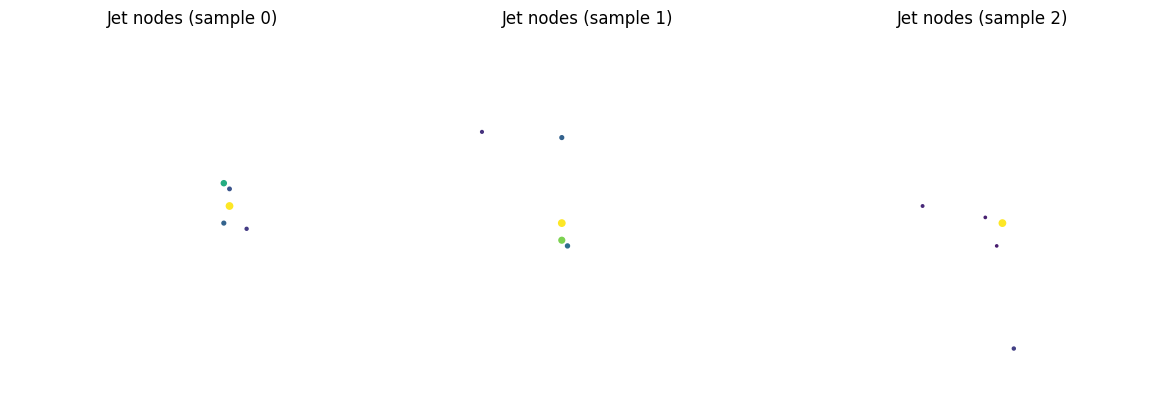

In [ ]:
def _to_single_channel(sample, channel=0):
    if sample.ndim == 3:
        return sample[..., channel]
    return sample

def _normalize_for_graph(img):
    img = img.astype(np.float32)
    if img.min() < 0:
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
    elif img.max() > 1.0:
        img = img / (img.max() + 1e-12)
    return img

def plot_jet_pixels(ax, img, quantile=0.98, max_nodes=2000, cmap="viridis"):
    """
    Each high-intensity pixel is its own node (no component merging).
    Node size is proportional to pixel intensity.
    """
    img_n = _normalize_for_graph(img)
    H, W = img_n.shape

    flat = img_n.flatten()
    thr = np.quantile(flat, quantile)
    coords = np.argwhere(img_n >= thr)

    # If too many nodes, keep top-k highest-intensity pixels
    if coords.shape[0] > max_nodes:
        top_idx = np.argsort(flat)[-max_nodes:]
        coords = np.column_stack(np.unravel_index(top_idx, img_n.shape))

    if coords.size == 0:
        ax.set_title("No jets found")
        ax.axis("off")
        return

    intens = img_n[coords[:, 0], coords[:, 1]]
    sizes = 20.0 * (intens + 0.05)

    ax.scatter(coords[:, 1], coords[:, 0], s=sizes, c=intens, cmap=cmap, vmin=0, vmax=1)
    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Jet pixels as nodes (intensity)")

num_samples_to_plot = 3
sample_indices = list(range(num_samples_to_plot))

fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(4 * num_samples_to_plot, 4))
if num_samples_to_plot == 1:
    axes = [axes]

for i, idx in enumerate(sample_indices):
    sample = _to_single_channel(data_X[idx], channel=0)
    plot_jet_pixels(axes[i], sample, quantile=0.999, max_nodes=500)
    axes[i].set_title(f"Jet nodes (sample {idx})")

plt.tight_layout()
plt.show()
